# Main Model Using Random Forest

The same code from the logistic regression model notebook `02_baseline_model.ipynb` for loading, cleaning, preprocessing, and splitting the data will be performed. For the random forest models, scaling is unnecessary and will not be done in this notebook. 

Basic workflow from the baseline model will be used in this notebook as well, i.e. build and evaluate a baseline model with minimal regularization then apply cross validation and a grid search of hyperparameters to handle potential overfitting risks. 

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

from src.data_loader import load_features
from src.preprocessing import clean_data, encode_categoricals
from src.split import patient_split, get_features_and_target
from src.evaluate import compute_metrics, evaluate_model

In [2]:
df = load_features()
df = clean_data(df)

train_df, test_df = patient_split(df)

X_train, y_train, ids_train = get_features_and_target(train_df)
X_test, y_test, ids_test = get_features_and_target(test_df)

X_train, X_test = encode_categoricals(X_train, X_test)

groups_train = ids_train['patient_nbr'] # will be used for group k-fold cross-validation

Loaded 101,766 rows, 54 columns.
Unique patients: 71,518

Columns with missing values:
race      2367
gender       3

Readmitted-within-30-days rate: 11.16%

  Dropped 2,423 rows with death/hospice discharge disposition.
  Dropped 3 rows with missing/invalid gender.
  Filled 2,320 missing race values with 'Unknown'.

Raw data: 101,766 encounters; Cleaned data: 99,340 encounters (2,426 dropped total).

Total encounters: 99,340 | Train: 79,462 (80.0%) | Test: 19,878 (20.0%)
Readmit rate - Full: 11.39% | Train: 11.36% | Test: 11.51%

Encoding 33 categorical columns: ['race', 'gender', 'admission_type', 'discharge_disposition', 'admission_source', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide_metformin', 'glipizide_metformin', 'glimepiride_p

### Baseline Random Forest Model

Unlike the baseline logistic regression, default random forest models are far more prone to overfitting. With no constraints, default random forest will continue to grow until all leaves are pure. This causes the decision trees to be extremely specific and memorize the training set rather than generalize. As such, it is expected that this baseline model will overfit and applying hyperparameter tuning will be necessary. 

In [3]:
rf_baseline = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

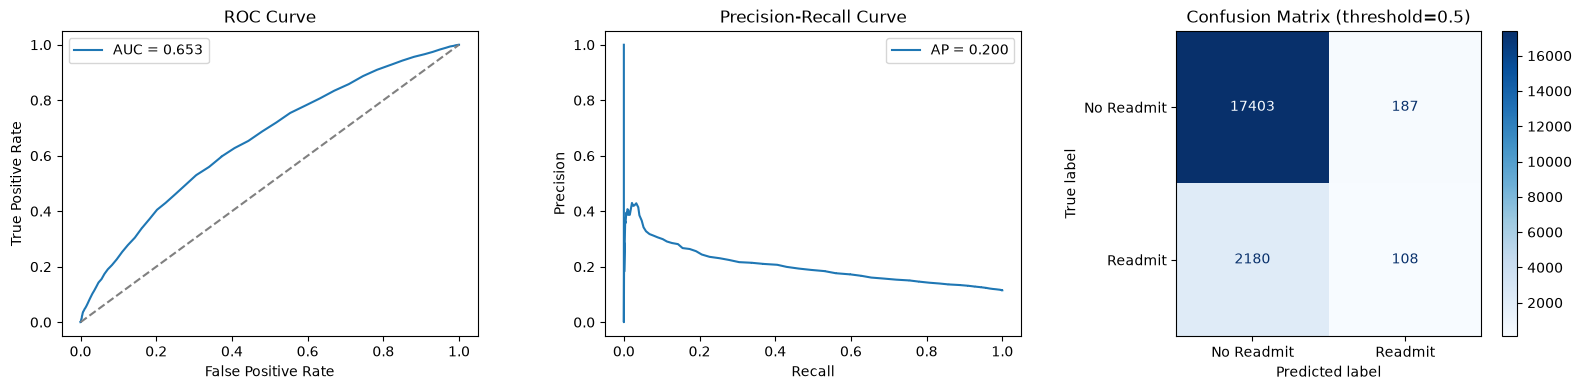

,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
train,1.000000,1.000000,0.999874,0.998893,1.000000,0.999446,0.5
test,0.653049,0.199956,0.880924,0.366102,0.047203,0.083624,0.5


In [4]:
y_train_pred_proba = rf_baseline.predict_proba(X_train)
y_test_pred_proba = rf_baseline.predict_proba(X_test)

train_metrics = compute_metrics(y_train, y_train_pred_proba)
test_metrics = evaluate_model(y_test, y_test_pred_proba)  # runs plots + returns dict

pd.DataFrame([train_metrics, test_metrics], index=["train", "test"])

### Observations on the Baseline Random Forest Model

Based on these initial results the model: 

- **clearly overfits**: The training set had near perfect metrics suggesting the model memorized the training set

- **was more accurate than logistic regression with the test set being 88% correct**: This is only due to the model having a bias for predicting the majority class. The class imbalance causes accuracy to be a misleading metric.

- **had extremely poor recall**: Recall was ~0.047, which means that the model caught <5% of the positive class. 

- **was worse at separability**: pr_auc of ~0.20. This reiterates the point of the model mainly predicting the majority class.

### Hyperparameter Tuning

With the baseline random forest model overfitting and the test set performing subpar, tuning hyperparameters is required. Like the logistic regression model, a grid search and cross validation (across 5 folds) was performed. 

### Hyperparameter Search Process

The final grid below reflects several rounds of iterative refinement (all grid searches had `n_estimators=400`):

1. **Expanded grid search**: 50 combinations which yielded slightly improved results from the baseline (pr_auc of ~0.21); overfitting still an issue

    `max_depth: [6,8,10,15,None]`, `min_samples_leaf: [5,20,50,100,150]`

2. **Second grid search**: Reduced the hyperparameters tested based on the best performing values from the previous grid search (this was done to reduce computation time). Added max_features as a hyperparameter, it was found that using 0.3 (30% of features) resulted in the most successful models. While the default of sqrt(num of features) (which is ~12-13 features) performed worse. 

    `max_depth: [None,15]`, `min_samples_leaf: [5,20]`, `max_features: ['sqrt','log2',0.3]`

3. **Third grid search**: was performed by testing more max_feature values (0.2, 0.3, 0.4) and trying more min_sample_leaf values [20, 35, 50]. This third search yielded the same results as the second, i.e. 0.3 optimal percent of features.

    `max_depth: [None,15]`, `min_samples_leaf: [20,35,50]`, `max_features: [0.2,0.3,0.4]`

4. **Final grid search**: was performed keeping max_features constant at 0.3 and testing various max_depth and min_sample_leaf values. Manual testing revealed the optimal depth fell in a range (6–12) the earlier grids had skipped entirely.

    `max_depth: [6,8,9,12]`, `min_samples_leaf: [10,20,30]`, `max_features: [0.3]`

In [5]:
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold

param_grid = {
    'n_estimators': [400],
    'max_depth': [6, 8, 9, 12],
    'min_samples_leaf': [10, 20, 30],
    'max_features': [0.3],
}

cv = StratifiedGroupKFold(n_splits=5)

rf_grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1
)

# Fit the grid search with the training data and groups for stratification
rf_grid_search.fit(X_train, y_train, groups=groups_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [6, 8, ...], 'max_features': [0.3], 'min_samples_leaf': [10, 20, ...], 'n_estimators': [400]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro...shuffle=False)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for ca

In [6]:
print(rf_grid_search.best_params_) # best model configuration
print(rf_grid_search.best_score_)  # mean CV PR-AUC of the winning combination

{'max_depth': 12, 'max_features': 0.3, 'min_samples_leaf': 10, 'n_estimators': 400}
0.220998967146495


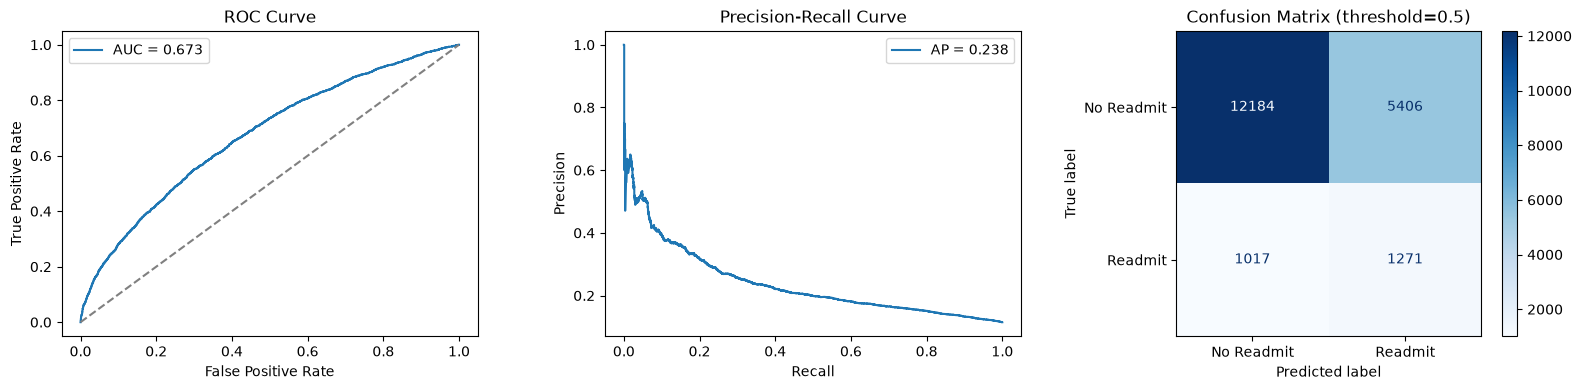

,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
train,0.795916,0.407649,0.710780,0.241326,0.721250,0.361647,0.5
test,0.673142,0.238318,0.676879,0.190355,0.555507,0.283547,0.5


In [7]:
# obtain the best model to be evaluated
best_model = rf_grid_search.best_estimator_

y_train_pred_proba_tuned = best_model.predict_proba(X_train)
y_test_pred_proba_tuned = best_model.predict_proba(X_test)

train_metrics_tuned = compute_metrics(y_train, y_train_pred_proba_tuned) # get train metrics to compare with test set
test_metrics_tuned = evaluate_model(y_test, y_test_pred_proba_tuned)  # plots + metrics

pd.DataFrame([train_metrics_tuned, test_metrics_tuned], index=["train", "test"])

In [8]:
# Display the top 10 hyperparameter combinations 
# these results were used to alter the hyperparameter grid for the previous iterations
results_df = pd.DataFrame(rf_grid_search.cv_results_)
results_df[['param_max_depth', 'param_min_samples_leaf', 'param_n_estimators', 'param_max_features', 'mean_test_score']].sort_values('mean_test_score', ascending=False).head(10)

,param_max_depth,param_min_samples_leaf,param_n_estimators,param_max_features,mean_test_score
9,12,10,400,0.3,0.220999
10,12,20,400,0.3,0.220552
11,12,30,400,0.3,0.219758
6,9,10,400,0.3,0.219638
7,9,20,400,0.3,0.219350
3,8,10,400,0.3,0.218689
8,9,30,400,0.3,0.218291
4,8,20,400,0.3,0.218042
5,8,30,400,0.3,0.217170
0,6,10,400,0.3,0.214332


### Grid Search Results

From looking at the top 10 best performing configurations, it is clear that max_depth=12 yielded the best results. The best model when evaluated on the test set had a pr_auc of 0.238 which is an improvement over both the logistic regression and baseline random forest models. 

However, the best model experienced some minor overfitting, the evaluation metrics between the train and test set had a gap in performance. Interestingly, the top 5 mean_test scores were fairly close suggesting perfomance plateaued. To be thorough, each of the top 5 model configurations was trained and the test set was evaluated. The code for the final random forest model is below. 

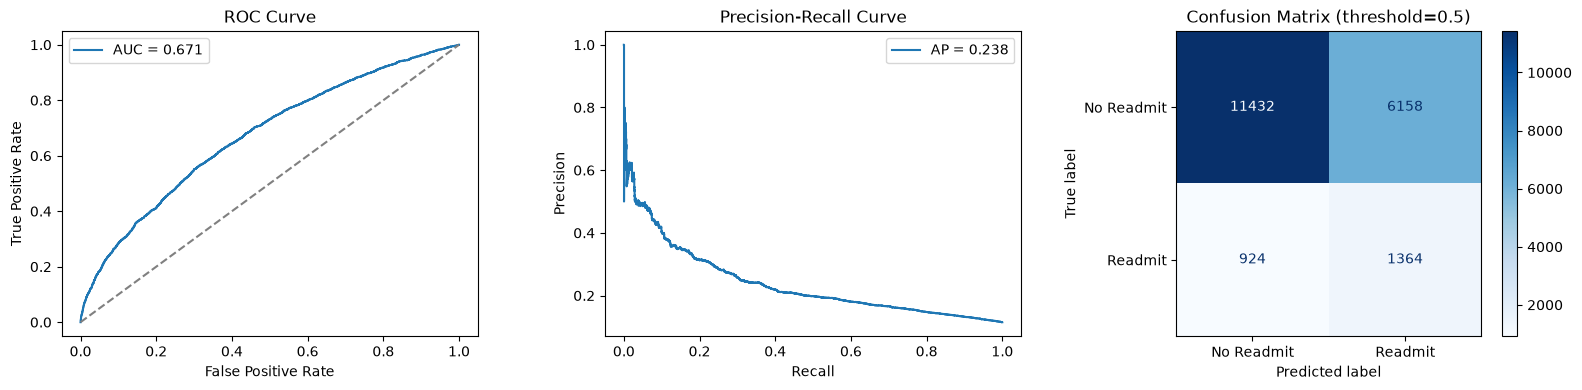

,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
train,0.715417,0.286751,0.656364,0.195881,0.652227,0.301279,0.5
test,0.670954,0.238158,0.643727,0.181335,0.596154,0.278084,0.5


In [9]:
# the finalized model
final_rf = RandomForestClassifier(
    max_depth=9, min_samples_leaf=20, n_estimators=400,
    class_weight='balanced', random_state=42, n_jobs=-1, max_features=0.3
)
final_rf.fit(X_train, y_train)

y_train_pred_proba_final = final_rf.predict_proba(X_train)
y_test_pred_proba_final = final_rf.predict_proba(X_test)

train_metrics_final = compute_metrics(y_train, y_train_pred_proba_final)
test_metrics_final = evaluate_model(y_test, y_test_pred_proba_final)

pd.DataFrame([train_metrics_final, test_metrics_final], index=["train", "test"])

In [10]:
importances_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_rf.feature_importances_
}).sort_values("importance", ascending=False)

importances_df.head(15)

,feature,importance
7,number_inpatient,0.370512
35,discharge_disposition_Discharged to home,0.101058
41,discharge_disposition_Discharged/transferred t...,0.061933
8,number_diagnoses,0.039675
6,number_emergency,0.037127
2,num_lab_procedures,0.037016
1,time_in_hospital,0.036098
4,num_medications,0.033320
0,age_numeric,0.033228
37,discharge_disposition_Discharged/transferred t...,0.019233


### Final Model Results

The final model chose had: 
- max_depth = 9
- min_samples_leaf = 20
- max_features = 0.3
- n_estimators = 400

This model was specifically chosen as it had minimal overfitting without sacrificing performance. Its test set results were comparable to the grid search chosen model as both yielded a pr_auc of ~0.238. 

**Feature Importance**: The top 4 features of the random forest model is identical to the most importance features in the logistic regression model. With number_inpatient visits as the most importance indicator of early admissions. Number of diagnoses and specific dischange dispositions were also fairly important in both models. 

### Threshold Sweep 

The current models have all been trained and tested at a threshold of 0.5, which may not be the optimal threshold. A threshold sweep was done to evaluate the final model perfomance at different thresholds. 

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_scores = y_test_pred_proba_final[:, 1]

threshold_range = np.arange(0.1, 0.9, 0.05)
sweep_results = []

# Sweep through thresholds and compute metrics (precision, recall, f1, accuracy) for each threshold
for t in threshold_range:
    y_pred_t = (y_scores >= t).astype(int)
    sweep_results.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred_t),
    })


sweep_df = pd.DataFrame(sweep_results)
sweep_df


,threshold,precision,recall,f1,accuracy
0,0.10,0.115102,1.000000,0.206442,0.115102
1,0.15,0.115102,1.000000,0.206442,0.115102
2,0.20,0.115191,0.999563,0.206576,0.116209
3,0.25,0.116892,0.991696,0.209134,0.136684
4,0.30,0.121549,0.964161,0.215883,0.193832
5,0.35,0.131785,0.902972,0.230003,0.304105
6,0.40,0.146448,0.804633,0.247796,0.437720
7,0.45,0.160552,0.726836,0.263008,0.531140
8,0.50,0.181335,0.596154,0.278084,0.643727
9,0.55,0.207953,0.447990,0.284052,0.740064


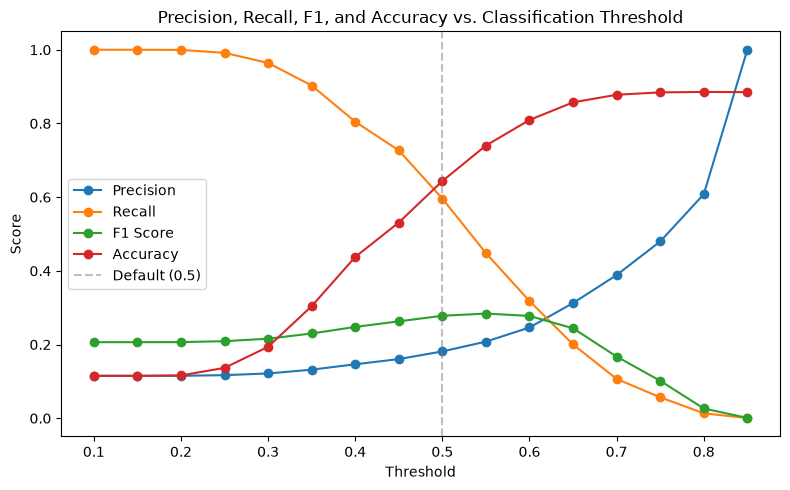

In [14]:
import matplotlib.pyplot as plt

    
plt.figure(figsize=(8, 5))
plt.plot(sweep_df["threshold"], sweep_df["precision"], label="Precision", marker='o')
plt.plot(sweep_df["threshold"], sweep_df["recall"], label="Recall", marker='o')
plt.plot(sweep_df["threshold"], sweep_df["f1"], label="F1 Score", marker='o')
plt.plot(sweep_df["threshold"], sweep_df["accuracy"], label="Accuracy", marker='o')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label="Default (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, F1, and Accuracy vs. Classification Threshold")
plt.legend()
plt.tight_layout()
plt.show()

### Threshold Sweep Results 

The optimal threshold appears to be around the default 0.5 value. F1 score is a good metric to balance recall and precision, F1 score peaks at 0.55 at a value of 0.284. This comes at the cost of recall which drops to ~0.448. Since recall should be prioritized (since we want to reduce false negatives), decreasing the threshold is prefered (threshold of 0.45-0.5).  

## Key Takeaways
- Unconstrained Random Forest overfit severely by default (train ROC-AUC 1.0 vs. test 0.65); tuning max_features, min_samples_leaf, and max_depth closed most of this gap.
- Final model: max_depth=9, max_features=0.3, min_samples_leaf=20, n_estimators=400, which was selected over the grid's top configurations.
- Test PR-AUC of 0.238 is a modest improvement over logistic regression's 0.226
- Feature importance broadly agrees with logistic regression and EDA findings (number_inpatient dominant in both), supporting that the signal is real.
- Recommended operating threshold: ~0.45–0.50, prioritizing recall given the HRRP framing, without sacrificing the tuned model's overall ranking quality. At threshold 0.45, the recall is ~0.727 with at the cost of precision being ~0.16